# 🗺️ Play Grid Demo — Geology Package

This notebook demonstrates the core workflow of the **Geology** package on a **10 × 10 synthetic grid**.

We will:
1. Synthesise borehole-style training points scattered on the grid
2. Assign geological unit labels to them
3. Grid them with `Geo_Gridder`
4. Fill missing cells with biharmonic inpainting (`in_paint`)
5. Run `one_vs_all` classification and visualise the result

> Grid size: **10 columns × 10 rows** — easy to reason about by eye before scaling up to real data.

## 0. Imports & Path Setup

In [ ]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# ---------------------------------------------------------------------------
# Make sure the gridder submodule is on the path
# ---------------------------------------------------------------------------
REPO_ROOT = os.path.abspath(os.path.dirname(''))   # notebook lives at repo root
for sub in ['gridder', os.path.join('geo_vtk', 'src')]:
    p = os.path.join(REPO_ROOT, sub)
    if p not in sys.path:
        sys.path.insert(0, p)

from gridder import Geo_Gridder

print(f"Repo root : {REPO_ROOT}")
print("Geo_Gridder imported OK")

Repo root : e:\karaouli\Projects\2025_ml_inpaint\github\Geology
Geo_Gridder imported OK


## 1. Build the 10 × 10 Play Grid

We define a unit grid from **(0,0)** to **(9,9)** and scatter **~25 labelled training points** across it,
leaving most cells empty so inpainting has work to do.

In [ ]:
import math

UNIT_NAMES  = {0: 'anthropogenic', 2: 'clay', 5: 'sand', 8: 'gravel'}
UNIT_COLORS = {0: '#C8C8C8',       2: '#009200', 5: '#FFFF00', 8: '#D8A320'}

# ---------------------------------------------------------------------------
# 10x10 grid parameters
# ---------------------------------------------------------------------------
GRID_N  = 10          # number of cells per side
GRID_DX = 1.0         # cell spacing (metres)

# ---------------------------------------------------------------------------
# Layers dip at 30 degrees (layers rise from right to left).
# Unit is determined by the layer-perpendicular coordinate:
#   y_eff = y - tan(30deg) * x
#
#   y_eff  > 5.5  ->  gravel (8)  -- top-left band
#   2.5 < y_eff <= 5.5 ->  sand  (5)  -- upper-middle band
#   0.0 < y_eff <= 2.5 ->  clay  (2)  -- lower-middle band
#   y_eff <= 0.0  ->  anthropogenic (0) -- bottom-right band
#
# Gravel dips out of the grid by x~7; anthropogenic fills the bottom-right.
# ---------------------------------------------------------------------------
TAN30 = math.tan(math.radians(30))   # ~0.5774

RAW_DATA = [
    #  x    y   unit
    # --- gravel (top-left, y_eff > 5.5) ---
    (0.5, 8.5, 8), (1.5, 7.5, 8),
    (3.5, 9.5, 8), (4.5, 9.0, 8),
    (5.5, 9.5, 8), (6.5, 9.5, 8),
    # --- sand (2.5 < y_eff <= 5.5) ---
    (0.5, 4.5, 5), (2.5, 5.5, 5),
    (3.5, 5.5, 5), (4.5, 6.0, 5),
    (5.5, 7.0, 5), (6.5, 7.5, 5),
    (7.5, 8.5, 5), (8.5, 8.5, 5),
    # --- clay (0.0 < y_eff <= 2.5) ---
    (0.5, 1.5, 2), (2.5, 2.0, 2),
    (3.5, 3.5, 2), (4.5, 4.0, 2),
    (5.5, 4.5, 2), (6.5, 5.0, 2),
    (7.5, 6.0, 2), (8.5, 6.5, 2), (9.5, 7.0, 2),
    # --- anthropogenic (y_eff <= 0.0, bottom-right) ---
    (3.5, 1.5, 0), (4.5, 2.0, 0),
    (5.5, 2.5, 0), (6.5, 3.0, 0),
    (7.5, 3.5, 0), (8.5, 4.0, 0), (9.5, 4.5, 0),
]

RAW_DATA      = np.array(RAW_DATA)
training_pts  = RAW_DATA[:, :2]
training_data = RAW_DATA[:, 2].astype(int)

print(f"Training points : {len(training_pts)}")
print(f"Grid will be    : {GRID_N} x {GRID_N}  =  {GRID_N**2} cells")
print(f"Fill ratio      : {len(training_pts)/GRID_N**2:.0%}  (rest is for inpainting)")
print(f"Dip angle       : 30 deg  (tan = {TAN30:.4f})")


## 2. Visualise the Raw Training Points on the Grid

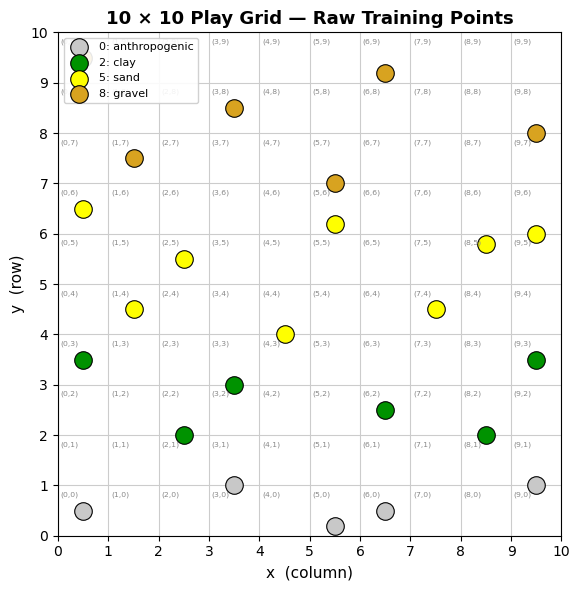

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

# Draw the 10x10 grid lines
for i in range(GRID_N + 1):
    ax.axhline(i, color='#CCCCCC', linewidth=0.8, zorder=0)
    ax.axvline(i, color='#CCCCCC', linewidth=0.8, zorder=0)

# Plot each training point coloured by geological unit
for unit_idx, name in UNIT_NAMES.items():
    mask = training_data == unit_idx
    ax.scatter(
        training_pts[mask, 0], training_pts[mask, 1],
        c=UNIT_COLORS[unit_idx], s=160, edgecolors='k', linewidths=0.8,
        zorder=3, label=f"{unit_idx}: {name}"
    )

# Cell coordinate labels
for row in range(GRID_N):
    for col in range(GRID_N):
        ax.text(col + 0.05, row + 0.88, f"({col},{row})",
                fontsize=5.5, color='#888888', va='top')

ax.set_xlim(0, GRID_N)
ax.set_ylim(0, GRID_N)
ax.set_xticks(np.arange(GRID_N + 1))
ax.set_yticks(np.arange(GRID_N + 1))
ax.set_xlabel('x  (column)', fontsize=11)
ax.set_ylabel('y  (row)',    fontsize=11)
ax.set_title('10 × 10 Play Grid — Raw Training Points', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 3. Grid the Training Points with `Geo_Gridder`

`make_grid(pts=(10, 10))` creates a **10 × 10** regular grid; `gridder()` bins the training points into it using the **mode** (most common value per cell).

In [ ]:
# ---------------------------------------------------------------------------
# Instantiate Geo_Gridder and build the grid
# ---------------------------------------------------------------------------
gg = Geo_Gridder(
    training_points = training_pts.astype(float),
    training_data   = training_data.astype(float),
    method          = 'mode',        # best for categorical labels
)

gg.make_grid(
    xmin=0, xmax=GRID_N - 1,
    ymin=0, ymax=GRID_N - 1,
    pts=(GRID_N, GRID_N)   # node coords 0..N-1, one node per cell
)

gg.gridder()   # fills gg.bs  (shape: ny x nx)

print("Gridded array (gg.bs):")
print(gg.bs)
print(f"\nShape: {gg.bs.shape}   (rows=y, cols=x)")
print(f"NaN count (empty cells): {np.sum(np.isnan(gg.bs))}")

## 4. Visualise the Gridded (Sparse) Result

Each coloured cell has at least one training point; grey cells are **NaN** — awaiting inpainting.

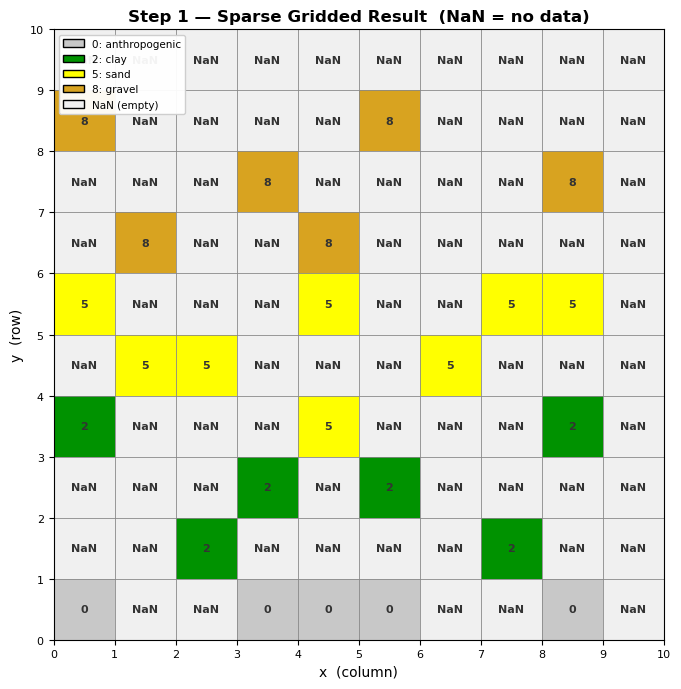

In [ ]:
# ---------------------------------------------------------------------------
# Helper: draw a labelled 10x10 grid from a (10,10) array
# ---------------------------------------------------------------------------
# IMOD colour map (indices 0-9) — same as used inside Geo_Gridder
imod_colors = np.array([
    [200,200,200],  # 0 anthropogenic
    [157, 78, 64],  # 1 peat
    [  0,146,  0],  # 2 clay
    [194,207, 92],  # 3 silt
    [255,255,255],  # 4 nothing
    [255,255,  0],  # 5 sand
    [243,225,  6],  # 6 sand(m)
    [231,195, 22],  # 7 sand(c)
    [216,163, 32],  # 8 gravel
    [ 95, 95,255],  # 9 shells
]) / 255.0

imod_labels = ['anthropogenic','peat','clay','silt','nothing',
               'sand','sand(m)','sand(c)','gravel','shells']

def plot_grid(arr, title, ax=None, show_values=True):
    """Render a (ny, nx) geological unit array as a colour grid."""
    ny, nx = arr.shape
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    # Grid lines
    for i in range(ny + 1):
        ax.axhline(i, color='#888', lw=0.6)
    for j in range(nx + 1):
        ax.axvline(j, color='#888', lw=0.6)
    # Colour each cell
    present_units = set()
    for row in range(ny):
        for col in range(nx):
            val = arr[row, col]
            if np.isnan(val):
                fc = '#F0F0F0'  # empty / NaN
                txt = 'NaN'
            else:
                idx = int(val)
                fc  = imod_colors[idx] if idx < len(imod_colors) else [0.5,0.5,0.5]
                txt = str(idx)
                present_units.add(idx)
            rect = plt.Rectangle((col, row), 1, 1,
                                  facecolor=fc, edgecolor='none', zorder=1)
            ax.add_patch(rect)
            if show_values:
                ax.text(col + 0.5, row + 0.5, txt,
                        ha='center', va='center', fontsize=8,
                        color='#333333', fontweight='bold', zorder=2)
    # Legend patches
    patches = [mpatches.Patch(facecolor=imod_colors[u], edgecolor='k',
                               label=f"{u}: {imod_labels[u]}")
               for u in sorted(present_units)]
    patches.append(mpatches.Patch(facecolor='#F0F0F0', edgecolor='k', label='NaN (empty)'))
    ax.legend(handles=patches, loc='upper left', fontsize=7.5,
              framealpha=0.95, ncol=1)
    ax.set_xlim(0, nx);  ax.set_ylim(0, ny)
    ax.set_xticks(np.arange(nx + 1));  ax.set_yticks(np.arange(ny + 1))
    ax.set_xticklabels(np.arange(nx + 1), fontsize=8)
    ax.set_yticklabels(np.arange(ny + 1), fontsize=8)
    ax.set_xlabel('x  (column)', fontsize=10)
    ax.set_ylabel('y  (row)',    fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    return ax

# Show sparse gridded result
fig, ax = plt.subplots(figsize=(7, 7))
plot_grid(gg.bs, 'Step 1 — Sparse Gridded Result  (NaN = no data)', ax=ax)
plt.tight_layout()
plt.show()

## 5. Biharmonic Inpainting  —  `in_paint()`

`in_paint()` uses `skimage.restoration.inpaint_biharmonic` to propagate known values smoothly into the empty cells.
This is the core algorithm of the package.

In [ ]:
# in_paint() stores the result in gg.prediction_data
# no_x / no_y are the output resolution (we keep it 10x10 for the demo)
gg.in_paint(no_x=GRID_N, no_y=GRID_N)

print("Inpainted array (gg.prediction_data):")
print(np.round(gg.prediction_data, 2))
print(f"\nShape  : {gg.prediction_data.shape}")
print(f"NaN remaining: {np.sum(np.isnan(gg.prediction_data))}")

No of points:100, data points:25, inpainted data:75

Inpainting....
Inpainted array (gg.inpainted_data):


## 6. One-vs-All Classification  —  `one_vs_all()`

The biharmonic result is a **continuous** field; `one_vs_all()` rounds it to the nearest integer geological label,
producing the final classified model.

In [ ]:
# one_vs_all classifies the continuous inpainted field into integer unit codes.
# The result is stored in gg.prediction_data
gg.one_vs_all()

print("Classified model (gg.prediction_data):")
print(gg.prediction_data)
print(f"\nUnique units found: {np.unique(gg.prediction_data).tolist()}")

## 7. Side-by-Side Comparison

Left: sparse gridded data.  
Right: fully inpainted + classified geological model.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_grid(gg.bs,    'Before  — Sparse Gridded Data',        axes[0], show_values=True)
plot_grid(gg.prediction_data, 'After  —  Inpainted + Classified Model', axes[1], show_values=True)

# Overlay original training points on the classified model
for unit_idx in UNIT_NAMES:
    mask = training_data == unit_idx
    axes[1].scatter(
        training_pts[mask, 0] + 0.5,   # centre of cell
        training_pts[mask, 1] + 0.5,
        marker='*', s=120, c='black', zorder=5
    )
axes[1].text(
    0.01, 0.01, '★ = original borehole points',
    transform=axes[1].transAxes, fontsize=8, color='black',
    va='bottom', style='italic'
)

plt.suptitle('Geology Package — 10×10 Play Grid Demo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8. Summary

| Step | Method | What it does |
|------|--------|--------------|
| 1 | `Geo_Gridder(…, method='mode')` | Wraps training data |
| 2 | `.make_grid(pts=(10,10))` | Creates 10×10 regular grid |
| 3 | `.gridder()` | Bins points into cells (→ `gg.bs`) |
| 4 | `.in_paint(no_x=10, no_y=10)` | Biharmonic inpainting of NaN cells (→ `gg.prediction_data`) |
| 5 | `.one_vs_all()` | Classifies continuous field to integer units (→ `gg.prediction_data`) |

This exact workflow scales directly to real-world grids of hundreds or thousands of cells.